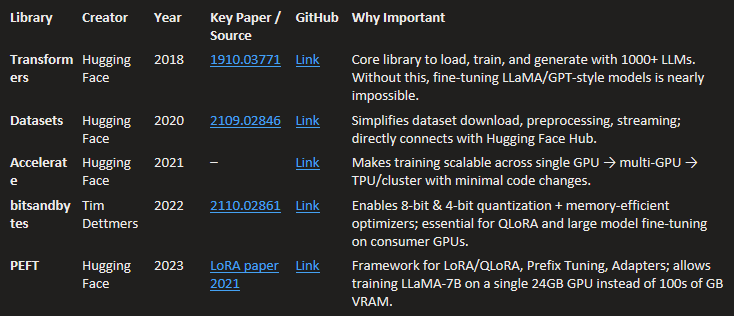

In [51]:
!pip install -U peft bitsandbytes transformers accelerate

In [52]:
!pip install -U trl

In [53]:
!pip install PyMuPDF

## Prebuilt data from huggingface data hub

In [54]:
from datasets import Dataset, load_dataset

In [55]:
dataset = load_dataset("roneneldan/TinyStories", split="train")

In [56]:
print(dataset)

Dataset({
    features: ['text'],
    num_rows: 2119719
})


In [57]:
print(dataset[0])

{'text': 'One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.\n\nLily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."\n\nTogether, they shared the needle and sewed the button on Lily\'s shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.'}


In [58]:
print(dataset[1])

{'text': 'Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.\n\nOne day, Beep was driving in the park when he saw a big tree. The tree had many leaves that were falling. Beep liked how the leaves fall and wanted to play with them. Beep drove under the tree and watched the leaves fall on him. He laughed and beeped his horn.\n\nBeep played with the falling leaves all day. When it was time to go home, Beep knew he needed more fuel. He went to the fuel place and got more healthy fuel. Now, Beep was ready to go fast and play again the next day. And Beep lived happily ever after.'}


In [59]:
print(dataset[2])

{'text': 'One day, a little fish named Fin was swimming near the shore. He saw a big crab and wanted to be friends. "Hi, I am Fin. Do you want to play?" asked the little fish. The crab looked at Fin and said, "No, I don\'t want to play. I am cold and I don\'t feel fine."\n\nFin felt sad but wanted to help the crab feel better. He swam away and thought of a plan. He remembered that the sun could make things warm. So, Fin swam to the top of the water and called to the sun, "Please, sun, help my new friend feel fine and not freeze!"\n\nThe sun heard Fin\'s call and shone its warm light on the shore. The crab started to feel better and not so cold. He saw Fin and said, "Thank you, little fish, for making me feel fine. I don\'t feel like I will freeze now. Let\'s play together!" And so, Fin and the crab played and became good friends.'}


## Our own custom data (non instrcution data) for domain specific finetuning

In [60]:
import fitz

In [61]:
def extract_text_from_pdf(pdf_path):
    text_blocks = []
    with fitz.open(pdf_path) as doc:
        for page in doc:
            text = page.get_text("text").strip()
            if text:
                text_blocks.append(text)
    return text_blocks

In [62]:
pdf_texts = extract_text_from_pdf("/content/Metformin.pdf")

In [63]:
pdf_texts

['Metformin is one of the most widely prescribed oral antihyperglycemic agents.\u200b\n Its primary mechanism of action involves the activation of AMP-activated protein kinase \n(AMPK), a central metabolic regulator that promotes glucose uptake and fatty acid oxidation \nwhile inhibiting hepatic gluconeogenesis.\u200b\n Beyond its glycemic control, Metformin has been shown to improve cardiovascular outcomes \nand display anti-inflammatory properties.\u200b\n Recent studies also suggest potential anticancer effects through inhibition of the mTOR \nsignaling pathway and suppression of tumor angiogenesis. \n \nClinical trials have demonstrated that combining Atorvastatin with Ezetimibe results in \nsignificant reductions in low-density lipoprotein cholesterol (LDL-C) levels compared to \nmonotherapy.\u200b\n Ezetimibe acts by inhibiting the Niemann–Pick C1-like 1 (NPC1L1) transporter in the intestinal \nwall, reducing cholesterol absorption, while Atorvastatin inhibits hepatic HMG-CoA red

| Model                        | Max Context Window (chunk length) during training | Approx words     | Comment                                                            |
| ---------------------------- | ------------------------------------------------- | ---------------- | ------------------------------------------------------------------ |
| **GPT-1 (2018)**             | 512 tokens                                        | ~350 words       | First transformer LM, small context                                |
| **GPT-2 (2019)**             | 1,024 tokens                                      | ~750 words       | Larger context for smoother coherence                              |
| **GPT-3 (2020)**             | 2,048 tokens                                      | ~1.5k words      | Trained on 300 B tokens with this window                           |
| **GPT-3.5 / ChatGPT (2022)** | 4,096 tokens                                      | ~3k words        | Used mixture of 2k–4k during pretraining + instruction fine-tuning |
| **GPT-4 (2023)**             | 8,192 – 32,768 – 1,28,000 tokens*                            | up to ~25k to 1L words | Multi-context variants (8k & 32k models)                           |


| Step                                     | What Happens                                                                             | Example                                     |
| ---------------------------------------- | ---------------------------------------------------------------------------------------- | ------------------------------------------- |
| **1️⃣ Data Collection**                  | Crawl text from web (Wikipedia, CommonCrawl, Books, PubMed, Code, etc.)                  | Billions of documents                       |
| **2️⃣ Cleaning / Filtering**             | Remove HTML, junk, duplicates, low-quality content                                       | Similar to your `strip()` & len filter      |
| **3️⃣ Splitting / Chunking**             | Split into paragraphs / segments using regex rules, sentence boundaries, or token length | Like your `re.split(r'\n\s*\n')`            |
| **4️⃣ Tokenization**                     | Convert text chunks → token IDs using BPE                                                | “The cat” → `[1012, 52, 199]`               |
| **5️⃣ Training (Next-Token Prediction)** | Model learns to predict the next token in each chunk                                     | Input: “The cat sat on the” → Target: “mat” |


In [64]:
import re
def split_paragraphs(pages):
    paragraphs = []
    for page_text in pages:
        # Split on double line breaks or long newlines
        chunks = re.split(r'\n\s*\n', page_text)
        for chunk in chunks:
            clean = chunk.strip()
            if len(clean) > 30:  # ignore too short lines
                paragraphs.append(clean)
    return paragraphs

In [65]:
paragraphs = split_paragraphs(pdf_texts)

In [66]:
data = [{"text": p} for p in paragraphs]

In [67]:
print(data)

[{'text': 'Metformin is one of the most widely prescribed oral antihyperglycemic agents.\u200b\n Its primary mechanism of action involves the activation of AMP-activated protein kinase \n(AMPK), a central metabolic regulator that promotes glucose uptake and fatty acid oxidation \nwhile inhibiting hepatic gluconeogenesis.\u200b\n Beyond its glycemic control, Metformin has been shown to improve cardiovascular outcomes \nand display anti-inflammatory properties.\u200b\n Recent studies also suggest potential anticancer effects through inhibition of the mTOR \nsignaling pathway and suppression of tumor angiogenesis.'}, {'text': 'Clinical trials have demonstrated that combining Atorvastatin with Ezetimibe results in \nsignificant reductions in low-density lipoprotein cholesterol (LDL-C) levels compared to \nmonotherapy.\u200b\n Ezetimibe acts by inhibiting the Niemann–Pick C1-like 1 (NPC1L1) transporter in the intestinal \nwall, reducing cholesterol absorption, while Atorvastatin inhibits he

[{'text': 'Metformin is one of the most widely prescribed oral antihyperglycemic agents.\u200b\n Its primary mechanism of action involves the activation of AMP-activated protein kinase \n(AMPK), a central metabolic regulator that promotes glucose uptake and fatty acid oxidation \nwhile inhibiting hepatic gluconeogenesis.\u200b\n Beyond its glycemic control, Metformin has been shown to improve cardiovascular outcomes \nand display anti-inflammatory properties.\u200b\n Recent studies also suggest potential anticancer effects through inhibition of the mTOR \nsignaling pathway and suppression of tumor angiogenesis.'},

{'text': 'Clinical trials have demonstrated that combining Atorvastatin with Ezetimibe results in \nsignificant reductions in low-density lipoprotein cholesterol (LDL-C) levels compared to \nmonotherapy.\u200b\n Ezetimibe acts by inhibiting the Niemann–Pick C1-like 1 (NPC1L1) transporter in the intestinal \nwall, reducing cholesterol absorption, while Atorvastatin inhibits hepatic HMG-CoA reductase, \nsuppressing endogenous cholesterol synthesis.\u200b\n The dual mechanism provides an additive lipid-lowering effect, particularly beneficial for \npatients with familial hypercholesterolemia who are unresponsive to statins alone.'},

{'text': 'The success of mRNA vaccines against SARS-CoV-2 has opened new pathways for rapid \nvaccine development.\u200b\n mRNA platforms enable flexible design and quick adaptation to emerging viral variants such as \nBQ.1 and XBB.1.5.\u200b\n Phase-II clinical trials have shown strong immunogenicity with elevated neutralizing antibody \ntiters and robust CD8⁺ T-cell responses.\u200b\n Ongoing research is exploring thermostable formulations and self-amplifying mRNA constructs \nto enhance global distribution and cost-efficiency.'},

{'text': 'Artificial intelligence (AI) is transforming pharmaceutical research by accelerating target \nidentification, molecular docking, and compound screening.\u200b\n Deep learning models trained on large-scale biological datasets can predict protein–ligand \nbinding affinities and optimize lead compounds.\u200b\n Integrating AI-driven insights with laboratory automation is reducing discovery timelines from \nyears to months.\u200b\n However, challenges remain regarding interpretability, bias mitigation, and regulatory validation \nfor AI-generated molecules.'}]

In [68]:
dataset = Dataset.from_list(data)

In [69]:
dataset

Dataset({
    features: ['text'],
    num_rows: 4
})

**LORA**

In [70]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

In [71]:
!pip install -U peft bitsandbytes transformers accelerate

**What each package does:**


*  PEFT (peft)
  Adds LoRA, QLoRA, adapters, prefix tuning, etc., so you can fine-tune large models with much less VRAM.
* bitsandbytes (bitsandbytes)
  Enables 8-bit/4-bit quantization for reduced memory usage and faster loading.
* Transformers (transformers)
  Main library for loading and using transformer models.
* Accelerate (accelerate)
  Simplifies multi-GPU, mixed precision, and distributed training.

In [72]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, TaskType
from datasets import load_dataset

In [73]:
model = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"

In [74]:
tokenizer = AutoTokenizer.from_pretrained(model)

# What it does:
# Downloads the tokenizer files from the Hugging Face model repository.
# Loads the correct tokenizer automatically based on the model type.
# Prepares text for the model by converting text → token IDs.

In [75]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

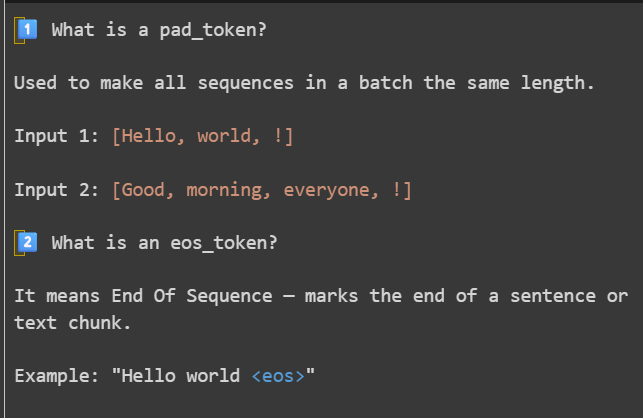

In [76]:
def tokenize_fn(examples):
    tokens = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=512
    )
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

1️⃣ Input

examples["text"]
→ This comes from your dataset, like:

{"text": "Metformin improves insulin sensitivity in the liver."}


2️⃣ Tokenization
tokens = tokenizer(examples["text"], truncation=True, padding="max_length", max_length=512)

| Argument               | Meaning                                                                              |
| ---------------------- | ------------------------------------------------------------------------------------ |
| `truncation=True`      | If the text is longer than 512 tokens, cut it off (keep only first 512).             |
| `padding="max_length"` | If the text is shorter than 512 tokens, pad it with `<pad>` tokens up to 512 length. |
| `max_length=512`       | Fixed sequence length per training example (standard size).                          |

{
  'input_ids': [1, 4382, 272, 98, ... , 2, 2, 2],
  'attention_mask': [1, 1, 1, ... , 0, 0, 0]
}

3️⃣ Labels

tokens["labels"] = tokens["input_ids"].copy()

This is the key step for causal (unsupervised) language modeling.

It means: “The model should try to predict the next token of this same sequence.”

Example:
| Input Tokens                 | Target Labels (Shifted Internally) |
| ---------------------------- | ---------------------------------- |
| `Metformin improves insulin` | `improves insulin sensitivity`     |

So model learns:

“Given previous words, predict the next word.”

That’s how GPT-style unsupervised training works — no Q/A, no instruction, just next-token prediction.

4️⃣ Output Returned

The final dictionary returned looks like this:

{

  "input_ids": [...],

  "attention_mask": [...],
  
  "labels": [...]

}

In [77]:
tokenized = dataset.map(tokenize_fn, batched=True)

Map:   0%|          | 0/4 [00:00<?, ? examples/s]

In [78]:
tokenized

Dataset({
    features: ['text', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 4
})

In [79]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

# Configure 8-bit quantization to reduce GPU memory usage
quantization_config = BitsAndBytesConfig(
    load_in_8bit=True  # Load model weights in 8-bit precision
)

# Load the pretrained causal language model
model = AutoModelForCausalLM.from_pretrained(
    model,  # Hugging Face model name or local path

    # Apply the quantization settings defined above
    quantization_config=quantization_config,

    # Automatically distribute the model across available devices
    # (GPU/CPU) depending on memory availability
    device_map="auto"
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [80]:
from peft import LoraConfig, TaskType

# Configure LoRA (Low-Rank Adaptation) for efficient fine-tuning
lora_config = LoraConfig(

    # Specify the task type:
    # CAUSAL_LM is used for autoregressive language models
    # like Llama, GPT, Mistral, Falcon, etc.
    task_type=TaskType.CAUSAL_LM,

    # Rank of the low-rank adaptation matrices
    # Smaller = less memory usage, larger = more learning capacity
    r=8,

    # Scaling factor for LoRA updates
    # Usually set to 2 * r
    lora_alpha=16,

    # Apply LoRA only to attention projection layers
    # q_proj = query projection
    # v_proj = value projection
    target_modules=["q_proj", "v_proj"],

    # Dropout applied to LoRA layers during training
    # Helps reduce overfitting
    lora_dropout=0.05,

    # Do not train bias parameters
    # Keeps training lightweight and memory-efficient
    bias="none"
)

In [81]:
from peft import get_peft_model

# Add LoRA adapters to the base model
# This wraps the original model with PEFT (Parameter-Efficient Fine-Tuning)
non_inst_model_lora = get_peft_model(
    model,         # Base pretrained model
    lora_config    # LoRA configuration defined earlier
)

# The resulting model now contains trainable LoRA adapter layers
# while most original model weights remain frozen.
#
# Benefits:
# - Lower GPU memory usage
# - Faster training
# - Smaller checkpoint sizes
# - Efficient fine-tuning of large LLMs

In [82]:
args = TrainingArguments(
    output_dir="./tinyllama-lora",
    num_train_epochs=5,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=20,
    save_total_limit=1,
    report_to="none"
)

| Parameter                       | Purpose                | Typical Range | Effect                      |
| ------------------------------- | ---------------------- | ------------- | --------------------------- |
| **output_dir**                  | Save model/checkpoints | Folder path   | Where your model ends up    |
| **overwrite_output_dir**        | Allow overwrite        | True / False  | Avoids folder conflicts     |
| **num_train_epochs**            | Training cycles        | 1–5           | More = longer training      |
| **per_device_train_batch_size** | Batch per GPU          | 1–8 (Colab)   | Affects speed & memory      |
| **save_steps**                  | Save frequency         | 100–1000      | More = frequent checkpoints |
| **save_total_limit**            | Keep last N            | 1–3           | Saves disk                  |
| **logging_steps**               | Log every X steps      | 20–100        | For progress monitoring     |
| **learning_rate**               | Weight update rate     | 1e-5–5e-5     | Controls stability          |
| **fp16**                        | Mixed precision        | True          | Faster + less memory        |
| **report_to**                   | Logging destination    | "none"        | Keeps it simple             |


In [83]:
from transformers import Trainer

# Create a Trainer object for model fine-tuning
trainer = Trainer(

    # Model to be trained
    # This is the LoRA-adapted model
    model=non_inst_model_lora,

    # Training configuration arguments
    # Includes batch size, epochs, learning rate,
    # logging, saving strategy, output directory, etc.
    args=args,

    # Tokenized training dataset
    # Contains input IDs, attention masks, labels, etc.
    train_dataset=tokenized
)

# The Trainer API handles:
# - Training loop
# - Gradient updates
# - Checkpoint saving
# - Logging
# - Evaluation (if provided)
# - Mixed precision support
# - Multi-GPU training

In [84]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


Step,Training Loss


TrainOutput(global_step=5, training_loss=9.63110122680664, metrics={'train_runtime': 14.5717, 'train_samples_per_second': 1.373, 'train_steps_per_second': 0.343, 'total_flos': 63629646888960.0, 'train_loss': 9.63110122680664, 'epoch': 5.0})

In [85]:
model_path = "/content/tinyllama-lora/checkpoint-5"

In [86]:
# tokenizer = AutoTokenizer.from_pretrained(model_path)

In [ ]:
!pip install --upgrade torchao

model = AutoModelForCausalLM.from_pretrained(model_path, device_map="auto")

In [88]:
prompt = "Clinical trials demonstrated that combining Atorvastatin with Ezetimibe"

In [89]:
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

In [90]:
# Generate text using the trained language model
outputs = model.generate(

    # Pass tokenized input tensors to the model
    # Includes input_ids, attention_mask, etc.
    **inputs,

    # Maximum number of new tokens to generate
    # Stops generation after 100 new tokens
    max_new_tokens=100,

    # Controls randomness in token selection
    # Lower = more deterministic
    # Higher = more creative/random
    temperature=0.8,

    # Nucleus sampling:
    # Selects tokens from the smallest set whose
    # cumulative probability >= 0.9
    top_p=0.9,

    # Enable sampling instead of greedy decoding
    # Required for temperature/top_p to have effect
    do_sample=True,

    # Penalizes repeated words/phrases
    # Helps reduce repetitive outputs
    repetition_penalty=1.1
)

# The generated output is a tensor of token IDs
# Convert it back to readable text using:
#
# decoded_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

[transformers] Both `max_new_tokens` (=100) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


In [91]:
print("\nModel Output:\n")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))


Model Output:

Clinical trials demonstrated that combining Atorvastatin with Ezetimibe was superior to placebo plus Ezetimibe in reducing the risk of cardiovascular events (hazard ratio 0.86, P < 0.05).
This drug has been approved by the US Food and Drug Administration (FDA) as an adjunct to diet and exercise for the treatment of patients with hypercholesterolemia and is marketed under the name Lipitor®. In a randomized, double-blind


In [92]:
questions = [
    "Explain the mechanism of action of Metformin.",
    "List two advantages of combining Atorvastatin with Ezetimibe.",
    "Summarize how mRNA vaccines work and mention one current research focus."
]


In [94]:
for q in questions:
    print("Question:", q)
    print("\n--- Non-instruction model ---")
    inputs = tokenizer(q, return_tensors="pt").to("cuda")
    outputs = model.generate(**inputs, max_new_tokens=80)
    print(tokenizer.decode(outputs[0], skip_special_tokens=True))

[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Question: Explain the mechanism of action of Metformin.

--- Non-instruction model ---


/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Explain the mechanism of action of Metformin.
Explain the mechanism of action of Metformin.
Metformin is a drug used to treat type 2 diabetes. It is a drug that is used to lower blood sugar levels. It is also used to treat other conditions such as polycystic ovary syndrome (PCOS), and nonalcoholic fatty liver disease (NAFLD
Question: List two advantages of combining Atorvastatin with Ezetimibe.

--- Non-instruction model ---


[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


List two advantages of combining Atorvastatin with Ezetimibe.
Answer: Atorvastatin is a statin drug that is used to lower cholesterol levels. Ezetimibe is a drug that is used to lower cholesterol levels. Combining these two drugs together can help to lower cholesterol levels.
List two disadvantages of combining Atorvastatin with Ezetimibe.

Question: Summarize how mRNA vaccines work and mention one current research focus.

--- Non-instruction model ---
Summarize how mRNA vaccines work and mention one current research focus.
The mRNA vaccines are a type of vaccine that uses genetic material to teach the body how to make a protein. The protein is then used to stimulate the immune system to make antibodies to fight the virus.
The mRNA vaccines are made from a piece of genetic material called mRNA. This mRNA is


### Non-Instruction Finetuning Dataset

In [ ]:
dataset = load_dataset("HuggingFaceFW/fineweb")
pubmed = load_dataset("ncbi/pubmed")
dataset = load_dataset("datajuicer/the-pile-pubmed-abstracts-refined-by-data-juicer")
dataset = load_dataset("open-llm-leaderboard/open_llm_corpus")
owt = load_dataset("Skylion007/openwebtext")
ds = load_dataset("armanc/scientific_papers")

### Instruction Finetuning Dataset

In [ ]:
https://huggingface.co/datasets/Amod/mental_health_counseling_conversations
https://huggingface.co/datasets/yahma/alpaca-cleaned
https://huggingface.co/datasets/Open-Orca/OpenOrca
https://huggingface.co/datasets/tatsu-lab/alpaca
https://huggingface.co/datasets/OpenAssistant/oasst1

## Prefrence Alignemnt tuing dataset

In [ ]:
https://huggingface.co/datasets/Anthropic/hh-rlhf
https://huggingface.co/datasets/argilla/ultrafeedback-binarized-preferences-cleaned
https://huggingface.co/datasets/xinlai/Math-Step-DPO-10K